In [ ]:
import numpy as np
import requests
from io import StringIO
from datetime import timedelta, datetime
from matplotlib.ticker import FormatStrFormatter
import matplotlib.font_manager as fm
from utils.functions_evaluation import *
font_path = "font-folder/Roboto-Regular.ttf"
font_path_bold = "font-folder/Roboto-Bold.ttf"
font_prop = fm.FontProperties(fname=font_path, size=20)  # Imposta la dimensione
font_prop_legend = fm.FontProperties(fname=font_path, size=16)
font_prop_title = fm.FontProperties(fname=font_path_bold, size=26)
import matplotlib as mpl
mpl.rcParams['font.family'] = font_prop.get_name()
import warnings
warnings.filterwarnings('ignore')

In [32]:
# Loading surveillance data: last surveillance file
season = '2024-2025'
if season == '2024-2025':
    df_surv = pd.read_csv("../../../input_data/target-hospital-admissions_2025-05-31.csv")
else:
    df_surv = pd.read_csv("../../../input_data/target-hospital-admissions_2024-04-27.csv")
df_surv.rename(columns={'date': 'target_end_date'}, inplace=True)
df_surv['target_end_date'] = pd.to_datetime(df_surv['target_end_date'])
df_surv

,target_end_date,location,location_name,hospitalizations,weekly_rate,horizon
0,2024-11-30,US,US,4270.0,1.274951,3
1,2024-12-07,US,US,6276.0,1.873909,4
2,2024-12-14,US,US,9143.0,2.729947,5
3,2024-12-21,US,US,15381.0,4.592510,6
4,2024-12-28,US,US,27617.0,8.245975,7
5,2025-01-04,US,US,38641.0,11.537558,8
6,2025-01-11,US,US,30672.0,9.158147,9
7,2025-01-18,US,US,32936.0,9.834140,10
8,2025-01-25,US,US,40555.0,12.109046,11
9,2025-02-01,US,US,51104.0,15.258802,12


In [33]:
# Loading jaccard similarity index data
if season == '2023-2024':
    df_t0 = pd.read_csv(f"../output_data/persistence_analysis/Jaccard_index_t0_Ens2_S2_LOP_wmape.csv", index_col=0)
    df_tprevious = pd.read_csv(f"../output_data/persistence_analysis/Jaccard_index_tprevious_Ens2_S2_LOP_wmape.csv", index_col=0)
elif season == '2024-2025':
    df_t0 = pd.read_csv(f"../output_data/persistence_analysis/Jaccard_index_t0_Ens2_S2_LOP_wmape_{season}.csv", index_col=0)
    df_tprevious = pd.read_csv(f"../output_data/persistence_analysis/Jaccard_index_tprevious_Ens2_S2_LOP_wmape_{season}.csv", index_col=0)


In [34]:
df_t0['target_end_date'] = pd.to_datetime(df_t0.index)
df_tprevious['target_end_date'] = pd.to_datetime(df_tprevious.index)
df_t0_surv = pd.merge(df_t0, df_surv[['target_end_date', 'hospitalizations']], on='target_end_date', how='inner')
df_tprevious_surv = pd.merge(df_tprevious, df_surv[['target_end_date', 'hospitalizations']], on='target_end_date', how='inner')

In [35]:
df_tprevious_surv

,0.05,0.15,0.25,0.5,0.75,target_end_date,hospitalizations
0,0.289958,0.425743,0.545763,0.755872,0.909548,2024-12-07,6276.0
1,0.556314,0.669311,0.757225,0.903967,0.953728,2024-12-14,9143.0
2,0.561644,0.726183,0.830590,0.927711,0.960447,2024-12-21,15381.0
3,0.698324,0.820359,0.862745,0.929342,0.956802,2024-12-28,27617.0
4,0.643243,0.811921,0.871921,0.933842,0.962134,2025-01-04,38641.0
5,0.341176,0.590698,0.707865,0.865412,0.934936,2025-01-11,30672.0
6,0.509934,0.685767,0.816010,0.924863,0.964106,2025-01-18,32936.0
7,0.727273,0.852404,0.900000,0.950802,0.973456,2025-01-25,40555.0
8,0.634409,0.732742,0.821814,0.946638,0.974311,2025-02-01,51104.0
9,0.764023,0.846154,0.890547,0.970614,0.984910,2025-02-08,54081.0


In [36]:
if season == '2024-2025':
    df_t0_surv = df_t0_surv[df_t0_surv['target_end_date'] <= '2025-03-22']
    df_tprevious_surv = df_tprevious_surv[df_tprevious_surv['target_end_date'] <= '2025-03-22']
else:
    df_t0_surv = df_t0_surv[df_t0_surv['target_end_date'] >= '2023-11-11']
    df_tprevious_surv = df_tprevious_surv[df_tprevious_surv['target_end_date'] >= '2023-11-11']
    df_t0_surv = df_t0_surv[df_t0_surv['target_end_date'] <= '2024-03-23']
    df_tprevious_surv = df_tprevious_surv[df_tprevious_surv['target_end_date'] <= '2024-03-23']

Visualizing Jaccard Similarity Index for k=15,25,50

In [37]:
k_values = ['0.15', '0.25', '0.5']
colors = ['#2d7974', '#4da284', '#80c799']
markers_t0 = 'o'  # Circle marker for t0
markers_tprevious = '^'  # Triangle marker for tprevious
k_values_perc = [15, 25, 50]
color_hosp = 'grey'

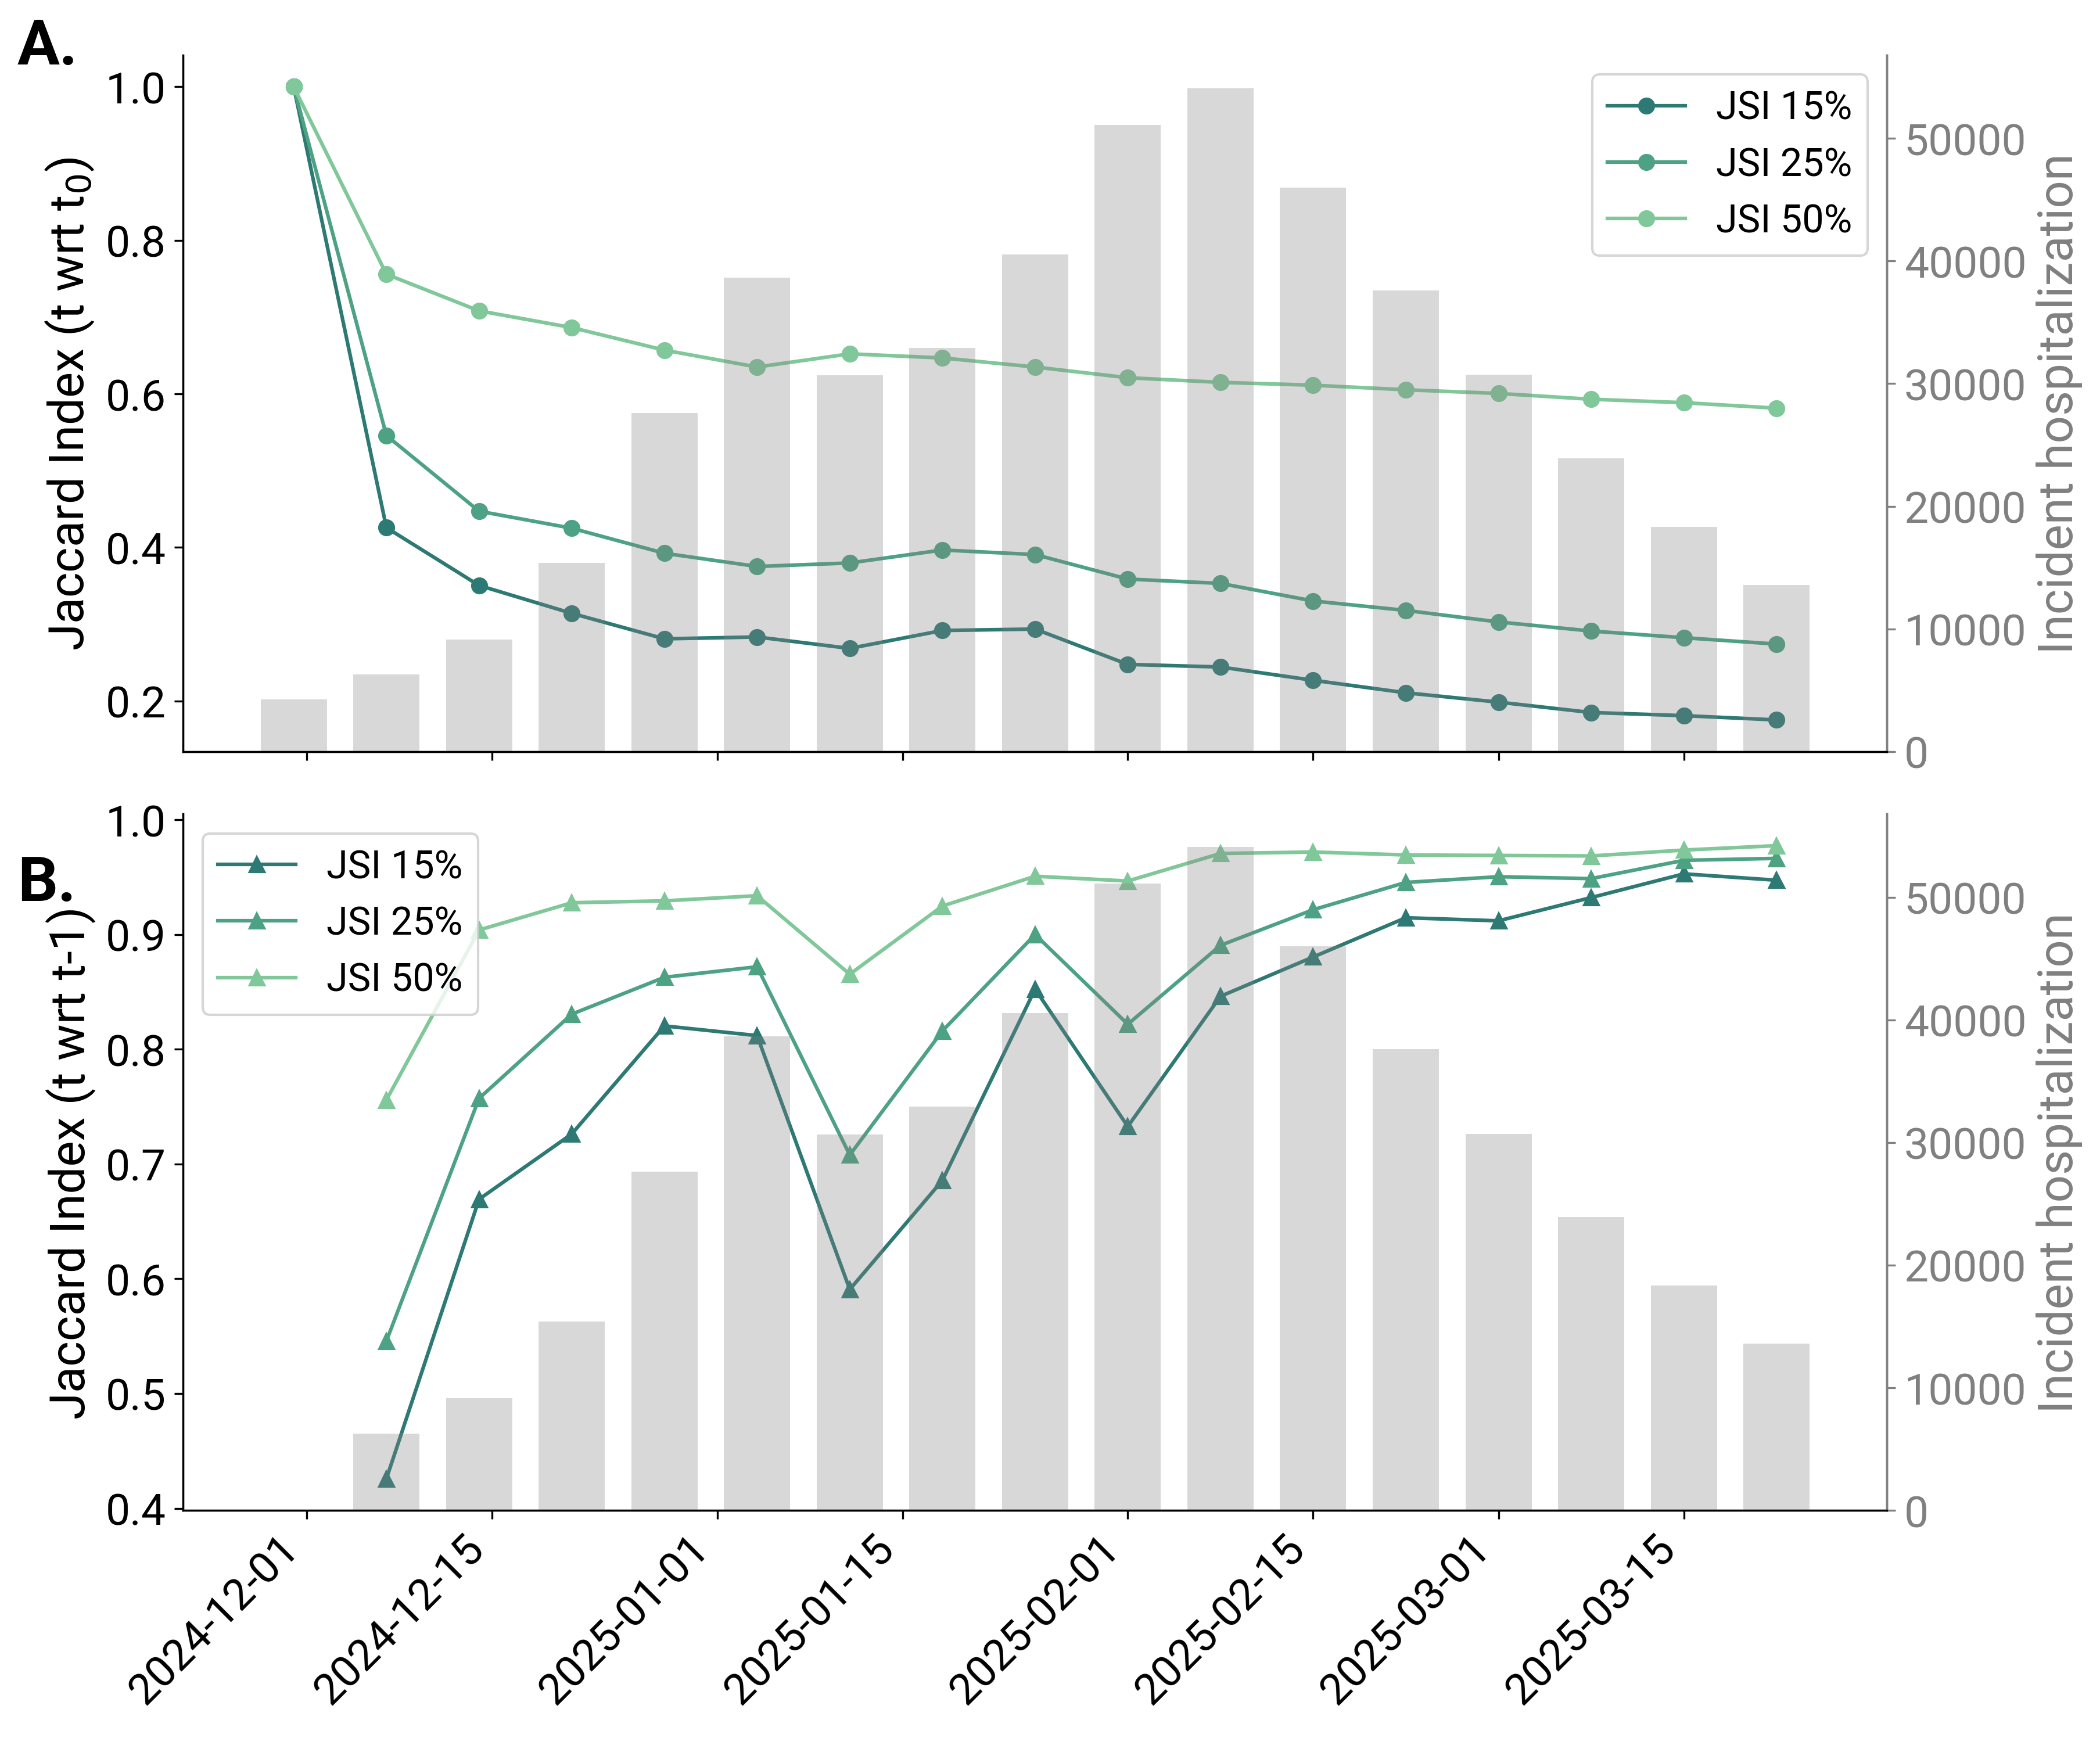

In [38]:
fig, axes = plt.subplots(2, 1, figsize=(12, 10), dpi=300, sharex=True)

# ----------- FIRST SUBPLOT: t0 -----------
ax1 = axes[0]
ax1_twin = ax1.twinx()
for i, k in enumerate(k_values):
    ax1.plot(df_t0_surv.target_end_date, df_t0_surv[k], f'-{markers_t0}', color=colors[i], label=f'JSI {k_values_perc[i]}%')
ax1_twin.bar(df_t0_surv.target_end_date, df_t0_surv.hospitalizations, color=color_hosp, alpha=0.3, width=5)
ax1.set_ylabel('Jaccard Index (t wrt t$_0$)', fontproperties=font_prop)
ax1_twin.set_ylabel('Incident hospitalization', color=color_hosp, fontproperties=font_prop)
ax1.legend(loc='upper right', prop = font_prop_legend)

# ------------ SECOND SUBPLOT: tprevious -----------
ax2 = axes[1]
ax2_twin = ax2.twinx()
for i, k in enumerate(k_values):
    ax2.plot(df_tprevious_surv.target_end_date, df_tprevious_surv[k], f'-{markers_tprevious}', color=colors[i], label=f'JSI {k_values_perc[i]}%')
ax2_twin.bar(df_tprevious_surv.target_end_date, df_tprevious_surv.hospitalizations, color=color_hosp, alpha=0.3, width=5)
ax2.set_xlabel(' ')
ax2.set_ylabel('Jaccard Index (t wrt t-1)',  fontproperties=font_prop)
ax2_twin.set_ylabel('Incident hospitalization', color=color_hosp,  fontproperties=font_prop)
ax2.legend(loc='upper left', prop = font_prop_legend)
for ax in [ax1, ax2, ax1_twin, ax2_twin]:
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontproperties(font_prop)
ax1.tick_params(axis='both', which='major', labelsize=18)
ax2.tick_params(axis='both', which='major', labelsize=18)
ax1_twin.tick_params(axis='y', labelsize=18, colors = color_hosp)
ax2_twin.tick_params(axis='y', labelsize=18, colors = color_hosp)
ax1_twin.tick_params(axis='both', which='major', labelsize=18)
ax2_twin.tick_params(axis='both', which='major', labelsize=18)
for ax in [ax1, ax2, ax1_twin, ax2_twin]:
    ax.spines['top'].set_visible(False)
ax1_twin.spines['right'].set_edgecolor(color_hosp)
ax2_twin.spines['right'].set_edgecolor(color_hosp)
# rotation of x-ticks when present
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, ha='right')
plt.tight_layout()
fig.text(0.0, 0.98, 'A.', font_properties=font_prop_title)
fig.text(0.0, 0.5, 'B.', font_properties=font_prop_title)
plt.show()
fig.savefig(f'../figures/jaccard_index_S2_LOP_supplementary_{season}.png', dpi = 300, bbox_inches='tight')